In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
# TASK A: BUILD THE DATA MODEL

# 1. Load Datasets
tickets = pd.read_csv('tickets.csv')
call_records = pd.read_csv('call_records.csv')
im_records = pd.read_csv('im_records.csv')

# 2. Convert timestamp columns to Datetime objects
tickets['Created'] = pd.to_datetime(tickets['Created'], errors='coerce')
call_records['Time'] = pd.to_datetime(call_records['Time'], errors='coerce')
im_records['Conversation start time'] = pd.to_datetime(im_records['Conversation start time'], errors='coerce')

# 3. Filter data for April 2026 only
start_date = '2026-04-01'
end_date = '2026-05-01' # Exclusive limit

tickets_apr = tickets[(tickets['Created'] >= start_date) & (tickets['Created'] < end_date)].copy()
call_apr = call_records[(call_records['Time'] >= start_date) & (call_records['Time'] < end_date)].copy()
im_apr = im_records[(im_records['Conversation start time'] >= start_date) & (im_records['Conversation start time'] < end_date)].copy()

# 4. Standardize Columns & Create Unified Data Model
# Tickets
df_tickets = tickets_apr[['ID', 'Created', 'Channel', 'Customer']].rename(columns={'Created': 'Date'})
df_tickets['Source'] = 'Tickets'

# Call Records (No explicit channel column, so we assign 'Phone Call')
df_calls = call_apr[['Call ID', 'Time', 'Customer']].rename(columns={'Call ID': 'ID', 'Time': 'Date'})
df_calls['Channel'] = 'Phone Call'
df_calls['Source'] = 'Call'

# IM Records
df_im = im_apr[['Dialogue ID', 'Conversation start time', 'Channel', 'Customer']].rename(columns={'Dialogue ID': 'ID', 'Conversation start time': 'Date'})
df_im['Source'] = 'IM'

# 5. Concatenate all to a single Unified Model
df_unified = pd.concat([df_tickets, df_calls, df_im], ignore_index=True)

# 6. Extract Date and Week for Time-Series Analysis
df_unified['DateOnly'] = df_unified['Date'].dt.date
df_unified['Week'] = df_unified['Date'].dt.isocalendar().week

print(f"Total Interaksi April 2026: {len(df_unified)} records\n")

Total Interaksi April 2026: 44926 records



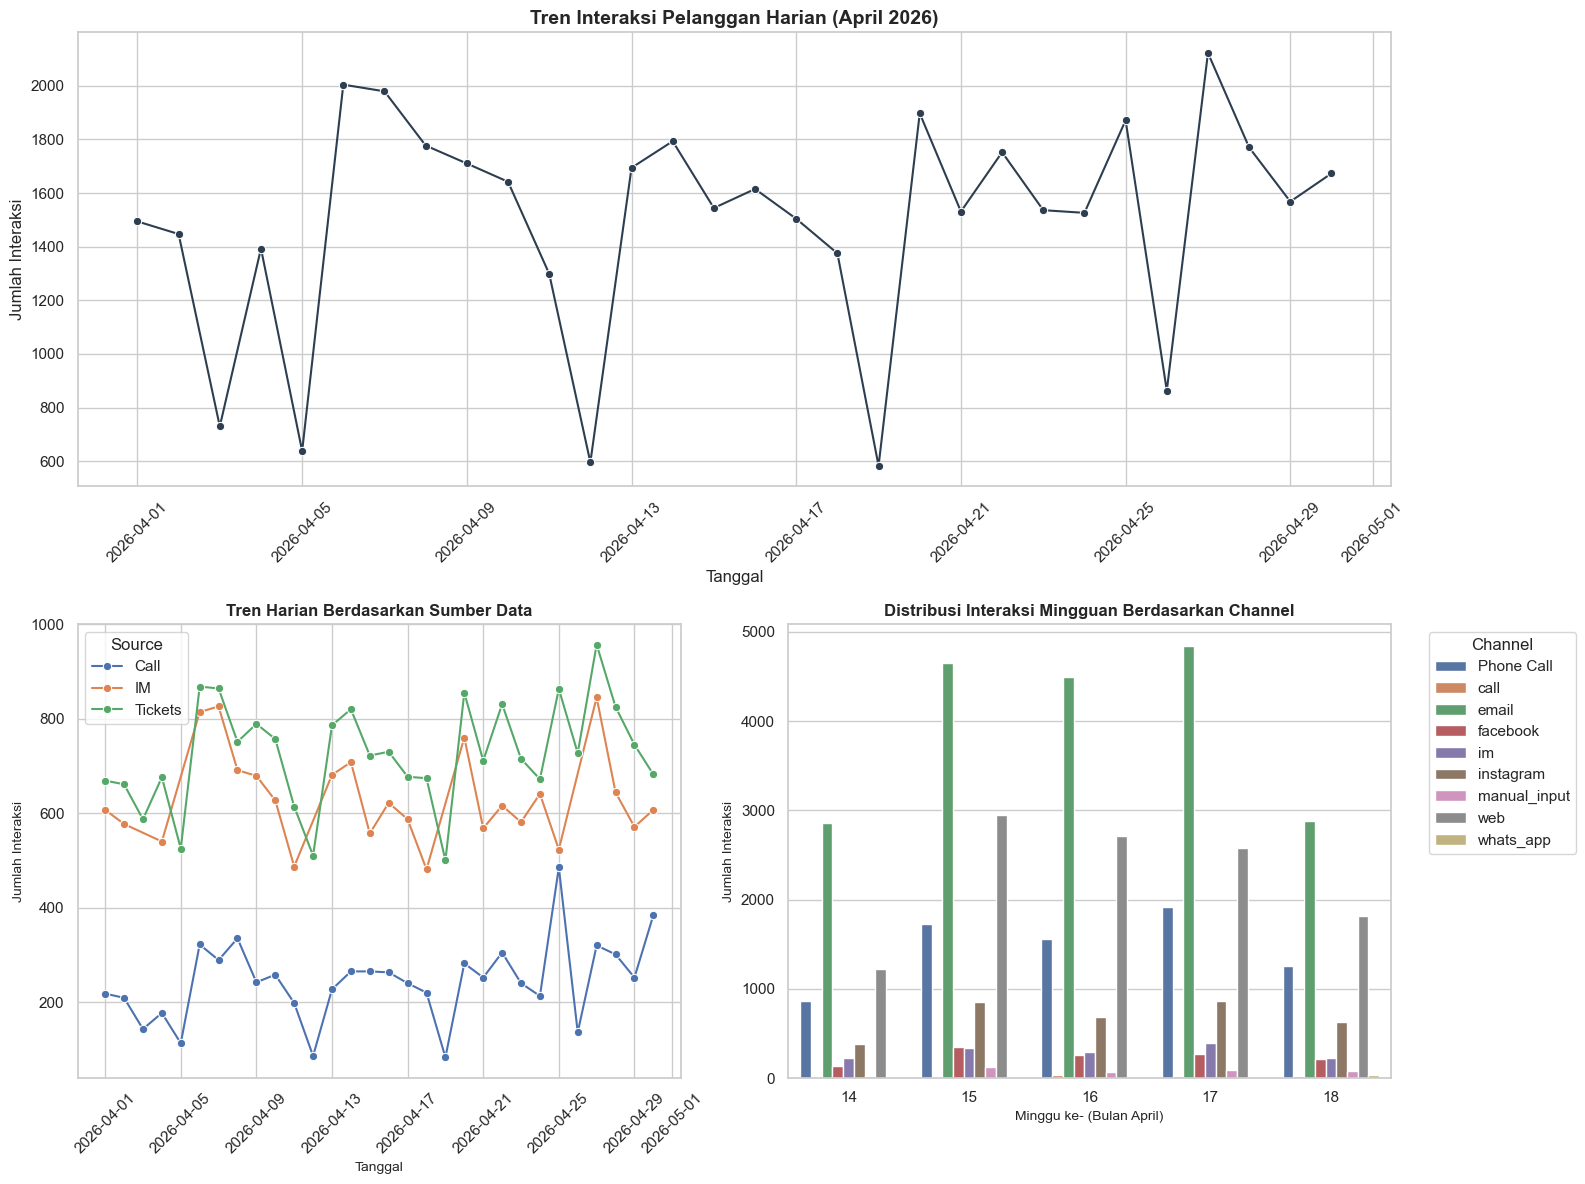

In [8]:
# TASK B: VISUALIZATIONS / DASHBOARD

# Setup figure sizes and aesthetic style
sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(16, 12))

# --- Plot 1: Daily Interaction Trend ---
ax1 = plt.subplot(2, 1, 1)
daily_trend = df_unified.groupby('DateOnly').size().reset_index(name='Total Interactions')
sns.lineplot(data=daily_trend, x='DateOnly', y='Total Interactions', marker='o', ax=ax1, color='#2c3e50')
ax1.set_title('Tren Interaksi Pelanggan Harian (April 2026)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tanggal', fontsize=12)
ax1.set_ylabel('Jumlah Interaksi', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# --- Plot 2: Daily Interaction Breakdowns by Source ---
ax2 = plt.subplot(2, 2, 3)
daily_source = df_unified.groupby(['DateOnly', 'Source']).size().reset_index(name='Interactions')
sns.lineplot(data=daily_source, x='DateOnly', y='Interactions', hue='Source', marker='o', ax=ax2)
ax2.set_title('Tren Harian Berdasarkan Sumber Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tanggal', fontsize=10)
ax2.set_ylabel('Jumlah Interaksi', fontsize=10)
ax2.tick_params(axis='x', rotation=45)

# --- Plot 3: Weekly Interaction Distribution by Channel ---
ax3 = plt.subplot(2, 2, 4)
weekly_channel = df_unified.groupby(['Week', 'Channel']).size().reset_index(name='Interactions')
# Using a bar plot for weekly comparison
sns.barplot(data=weekly_channel, x='Week', y='Interactions', hue='Channel', ax=ax3, errorbar=None)
ax3.set_title('Distribusi Interaksi Mingguan Berdasarkan Channel', fontsize=12, fontweight='bold')
ax3.set_xlabel('Minggu ke- (Bulan April)', fontsize=10)
ax3.set_ylabel('Jumlah Interaksi', fontsize=10)
ax3.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Insight 1: Pola Siklus Mingguan dan Penurunan Drastis di Akhir PekanTemuan: Tren interaksi pelanggan harian menunjukkan pola siklus yang sangat identik setiap minggunya, di mana total interaksi selalu anjlok secara drastis pada titik tertentu (berkorelasi dengan akhir pekan di tanggal 4-5, 11-12, 18-19, dan 25-26 April) lalu melonjak kembali pada awal minggu. Penurunan volume secara serentak ini juga konsisten terjadi di semua sumber data (Tickets, IM, maupun Call).   Rekomendasi: Lakukan efisiensi biaya operasional dengan menerapkan penjadwalan agen yang dinamis (dynamic rostering). Kurangi jumlah agen yang bertugas (headcount) pada hari libur atau akhir pekan, dan kerahkan kapasitas agen maksimal (termasuk on-call atau lembur) pada hari Senin hingga Rabu untuk mengurai tumpukan (backlog) tiket dari akhir pekan dan lonjakan kontak baru.

Insight 2: Dominasi Mutlak Saluran Asynchronous (Email dan Web)Temuan: Grafik distribusi mingguan membuktikan bahwa Email secara konsisten menjadi saluran dengan volume interaksi tertinggi yang melampaui 4000 interaksi pada minggu sibuk, disusul oleh saluran Web di posisi kedua. Saluran suara (Phone Call) hanya menempati urutan ketiga, sementara saluran sosial media (Instagram, Facebook, WhatsApp) mencatat volume yang sangat kecil.   Rekomendasi: Pusatkan investasi teknologi layanan dan pelatihan pada penanganan tiket berbasis teks. Karena Email dan Web paling banyak digunakan, implementasikan otomatisasi seperti template respons cepat, sistem klasifikasi tiket berbasis AI untuk Email, atau perkuat Knowledge Base / FAQ (Self-Service) di platform Web guna menekan volume kontak secara efektif (ticket deflection). Anda juga dapat merelokasi agen dari saluran sosial media (yang sepi interaksi) untuk membantu tim Email atau Web.

In [11]:
# 1. Load Datasets
call_records = pd.read_csv('call_records.csv')
im_records = pd.read_csv('im_records.csv')


# Untuk Call Records
call_records['Queuing_Sec'] = pd.to_timedelta(call_records['Queuing time'], errors='coerce').dt.total_seconds()
call_records['AHT_Sec'] = pd.to_timedelta(call_records['Processing Duration'], errors='coerce').dt.total_seconds()

# Untuk IM Records
im_records['Queuing_Sec'] = pd.to_timedelta(im_records['Queuing time(hours/minutes/seconds)'], errors='coerce').dt.total_seconds()
im_records['FRT_Sec'] = pd.to_timedelta(im_records['First response time(hours/minutes/seconds)'], errors='coerce').dt.total_seconds()
im_records['AHT_Sec'] = pd.to_timedelta(im_records['Duration(hours/minutes/seconds)'], errors='coerce').dt.total_seconds()



# MENGHITUNG METRIK

SLA_LIMIT_SECONDS = 300 # Asumsi SLA batas antre 5 menit

# 1. Average Queuing Time (AQT) & SLA Breach
call_aqt = call_records['Queuing_Sec'].mean()
call_sla_breach = (call_records['Queuing_Sec'] > SLA_LIMIT_SECONDS).mean() * 100

im_aqt = im_records['Queuing_Sec'].mean()
im_sla_breach = (im_records['Queuing_Sec'] > SLA_LIMIT_SECONDS).mean() * 100

# 2. First Response Time (FRT) - Abaikan nilai 0 jika ada
im_frt_avg = im_records[im_records['FRT_Sec'] > 0]['FRT_Sec'].mean()

# 3. Average Handling Time (AHT)
call_aht = call_records['AHT_Sec'].mean()
im_aht = im_records['AHT_Sec'].mean()

# 4. Abandonment Rate (Tingkat Diabaikan)
call_abandoned = call_records[(call_records['Hangup side'] == 'Customer') & (call_records['AHT_Sec'] <= 5)]
call_abandon_rate = (len(call_abandoned) / len(call_records)) * 100

im_abandon_rate = (len(im_records[im_records['How the dialogue ends'].str.contains('customer left|timeout', case=False, na=False)]) / len(im_records)) * 100


print("=== RINGKASAN METRIK OPERASIONAL ===")
print(f"1. AQT Phone Calls : {call_aqt:.2f} detik (SLA Breach: {call_sla_breach:.2f}%)")
print(f"   AQT IM / Chat   : {im_aqt:.2f} detik (SLA Breach: {im_sla_breach:.2f}%)")
print(f"2. FRT IM / Chat   : {im_frt_avg:.2f} detik")
print(f"3. AHT Phone Calls : {call_aht / 60:.2f} menit")
print(f"   AHT IM / Chat   : {im_aht / 60:.2f} menit")
print(f"4. Abandonment Call: {call_abandon_rate:.2f}%")
print(f"   Abandonment IM  : {im_abandon_rate:.2f}%")

=== RINGKASAN METRIK OPERASIONAL ===
1. AQT Phone Calls : 8.83 detik (SLA Breach: 0.00%)
   AQT IM / Chat   : 1036.39 detik (SLA Breach: 0.68%)
2. FRT IM / Chat   : 27.38 detik
3. AHT Phone Calls : 1.68 menit
   AHT IM / Chat   : 9.67 menit
4. Abandonment Call: 36.97%
   Abandonment IM  : 0.00%


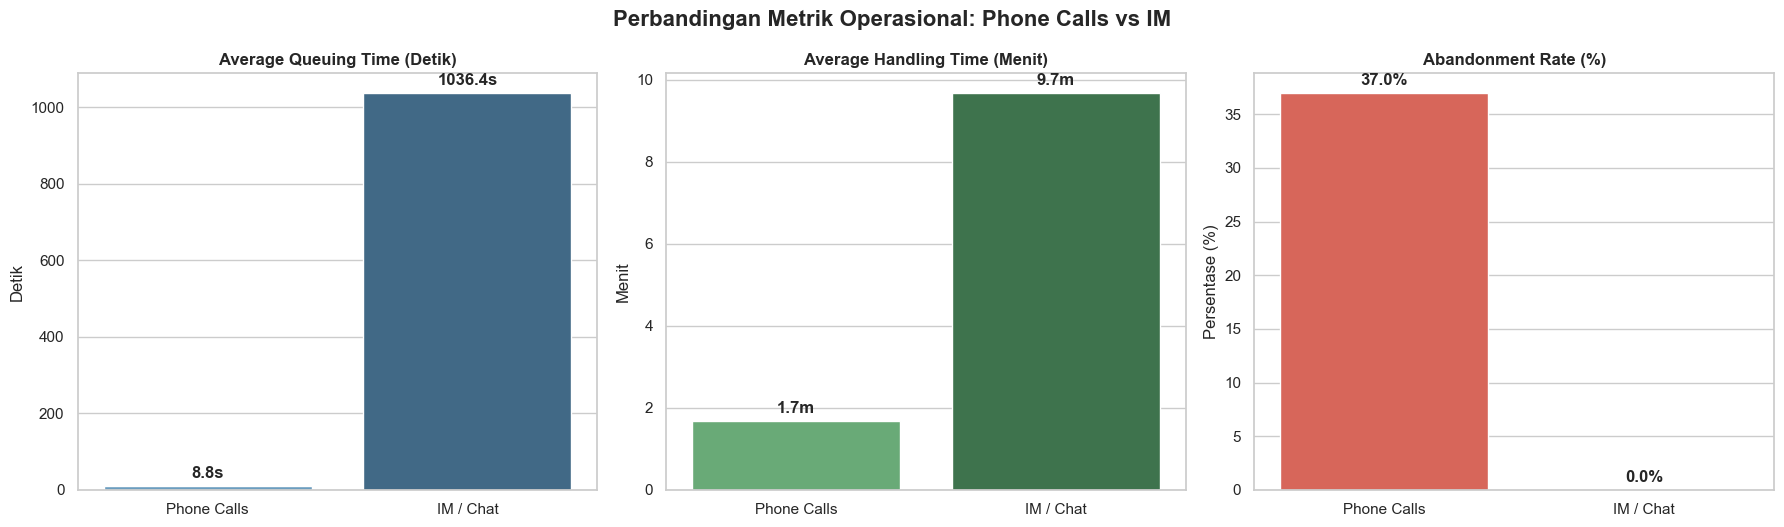

In [12]:
# VISUALISASI METRIK OPERASIONAL

categories = ['Phone Calls', 'IM / Chat']
aqt_data = [call_aqt, im_aqt]
aht_data = [call_aht / 60, im_aht / 60] # Konversi ke menit
abandonment_data = [call_abandon_rate, im_abandon_rate]
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Average Queuing Time (AQT) dalam Detik
sns.barplot(x=categories, y=aqt_data, ax=axes[0], palette="Blues_d")
axes[0].set_title('Average Queuing Time (Detik)', fontweight='bold')
axes[0].set_ylabel('Detik')
# Menambahkan label angka di atas bar
for i, v in enumerate(aqt_data):
    axes[0].text(i, v + (max(aqt_data)*0.02), f"{v:.1f}s", ha='center', fontweight='bold')

# Plot 2: Average Handling Time (AHT) dalam Menit
sns.barplot(x=categories, y=aht_data, ax=axes[1], palette="Greens_d")
axes[1].set_title('Average Handling Time (Menit)', fontweight='bold')
axes[1].set_ylabel('Menit')
for i, v in enumerate(aht_data):
    axes[1].text(i, v + (max(aht_data)*0.02), f"{v:.1f}m", ha='center', fontweight='bold')

# Plot 3: Abandonment Rate (%)
sns.barplot(x=categories, y=abandonment_data, ax=axes[2], palette="Reds_d")
axes[2].set_title('Abandonment Rate (%)', fontweight='bold')
axes[2].set_ylabel('Persentase (%)')
for i, v in enumerate(abandonment_data):
    axes[2].text(i, v + (max(abandonment_data)*0.02), f"{v:.1f}%", ha='center', fontweight='bold')

# Merapikan layout dan menampilkan grafik
plt.tight_layout()
plt.suptitle('Perbandingan Metrik Operasional: Phone Calls vs IM', y=1.05, fontsize=16, fontweight='bold')
plt.show()

1. Evaluasi Waktu Antre (AQT) pada Channel Instant Messaging (Chat)

Temuan: Meskipun rata-rata respons awal (FRT) sangat cepat (~27 detik), pelanggan yang terpaksa masuk antrean chat (tidak langsung dilayani) rata-rata menunggu lebih dari 17 menit (sekitar 1036 detik).

Rekomendasi: Perbedaan drastis ini menunjukkan kurangnya jumlah agen chat pada jam-jam sibuk (peak hours). Disarankan untuk menerapkan penjadwalan dinamis (dynamic shift rostering) dengan memindahkan beberapa agen dari jalur telepon (yang antreannya sangat rendah, AQT ~8 detik) ke jalur chat pada jam sibuk.

2. Tinjauan terhadap Durasi Penanganan (AHT) Panggilan

Temuan: Rata-rata durasi penanganan telepon sangat singkat (sekitar 1,68 menit) dibandingkan dengan chat (9,67 menit).

Rekomendasi: Mengingat tingginya abandonment rate, AHT yang terlalu singkat ini memperkuat dugaan bahwa banyak interaksi telepon yang tidak menghasilkan resolusi apa pun (First Contact Resolution rendah). Disarankan untuk membuat survei CSAT otomatis melalui SMS setelah telepon ditutup untuk memvalidasi apakah masalah mereka benar-benar selesai dalam 1,5 menit.

3. Investigasi Tingkat Abandonment Telepon yang Kritis (~37%)

Temuan: Sekitar 37% dari total panggilan diakhiri oleh pelanggan (Hangup side = Customer) dengan durasi kurang dari 5 detik.

Rekomendasi: Angka ini sangat tidak wajar. Hal ini sering kali mengindikasikan masalah teknis (panggilan terputus saat diangkat), agen yang melakukan ghosting (mengangkat telepon namun diam/mute), atau sistem IVR (Interactive Voice Response) yang membingungkan sehingga pelanggan mematikan telepon tepat saat tersambung. Manajemen harus segera melakukan audit teknis pada sistem PABX/Telepon dan memantau sampel rekaman panggilan yang berdurasi di bawah 5 detik.